# Dataset Plots For Thesis

This notebook collects clean input/output plots for the dataset section of the thesis.
It starts with the Darcy flow dataset used for `FNO2d`.

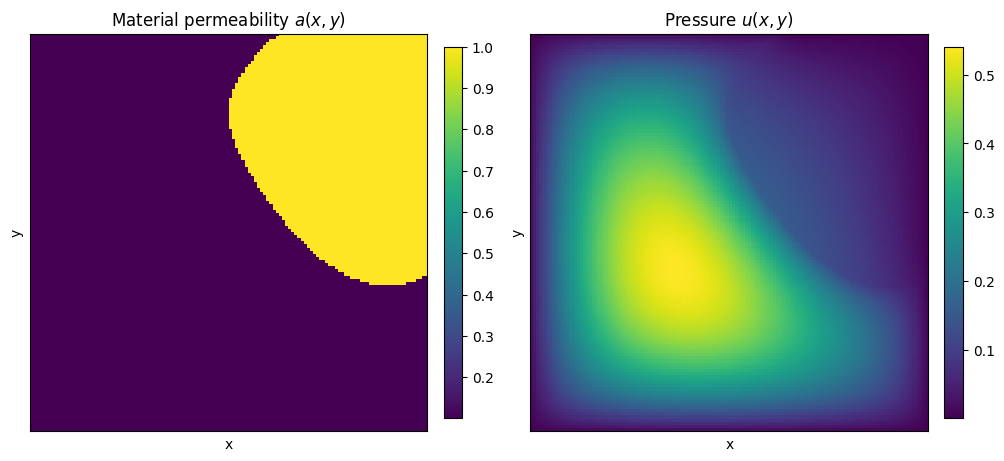

In [2]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Darcy flow dataset parameters
# -----------------------------
darcy_path = Path("/scratch/mnhagen/datasets/darcy_flow/darcy_beta1.h5")
sample_idx = 5
save_figure = False
save_path = Path("/home/mnhagen/thesis/figures/darcy_input_output.png")

if not darcy_path.exists():
    raise FileNotFoundError(f"Could not find Darcy dataset at {darcy_path}")

with h5py.File(darcy_path, "r") as f:
    permeability = np.array(f["nu"][sample_idx], dtype=np.float32)
    pressure = np.array(f["tensor"][sample_idx, 0], dtype=np.float32)
    xcoord = f["x-coordinate"][:]
    ycoord = f["y-coordinate"][:]

extent = [float(xcoord.min()), float(xcoord.max()), float(ycoord.min()), float(ycoord.max())]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

im0 = axes[0].imshow(permeability, origin="lower", extent=extent, cmap="viridis", aspect="equal")
axes[0].set_title("Material permeability $a(x,y)$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_xticks([])
axes[0].set_yticks([])
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(pressure, origin="lower", extent=extent, cmap="viridis", aspect="equal")
axes[1].set_title("Pressure $u(x,y)$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_xticks([])
axes[1].set_yticks([])
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

#fig.suptitle(f"Darcy flow sample {sample_idx}", fontsize=14)

if save_figure:
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure to {save_path}")

plt.show()

Saved figure to /home/mnhagen/thesis/figures/navier_input_output.png


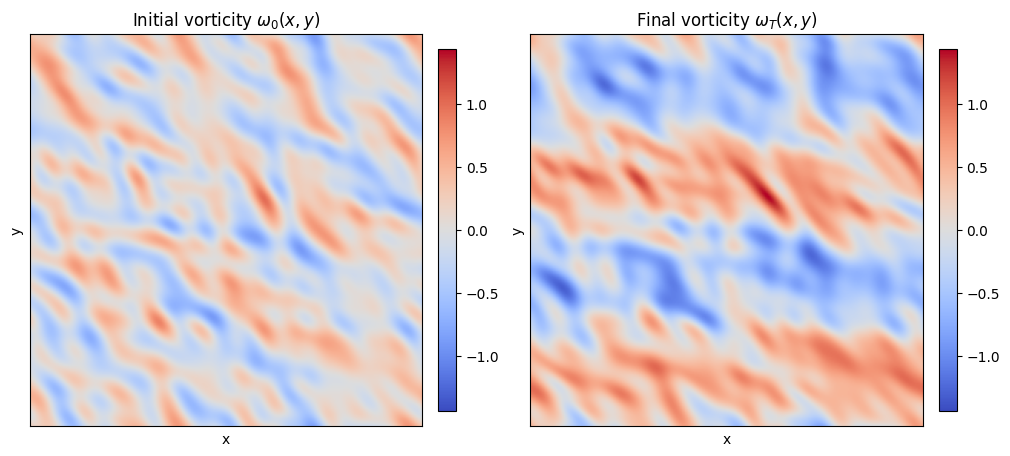

In [3]:
# --------------------------------------
# Navier-Stokes dataset: initial/final
# --------------------------------------
navier_path = Path("/scratch/mnhagen/datasets/navier_stokes_multires/navier_stokes2D_S1000_N256_multi.h5")
sample_idx = 5
save_figure = True
save_path = Path("/home/mnhagen/thesis/figures/navier_input_output.png")

if not navier_path.exists():
    raise FileNotFoundError(f"Could not find Navier-Stokes dataset at {navier_path}")

with h5py.File(navier_path, "r") as f:
    omega = np.array(f["omega"][sample_idx], dtype=np.float32)

omega_initial = omega[0]
omega_final = omega[-1]
extent = [0.0, 1.0, 0.0, 1.0]
vmax = float(max(np.abs(omega_initial).max(), np.abs(omega_final).max()))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

im0 = axes[0].imshow(omega_initial, origin="lower", extent=extent, cmap="coolwarm", aspect="equal", vmin=-vmax, vmax=vmax)
axes[0].set_title("Initial vorticity $\\omega_0(x,y)$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_xticks([])
axes[0].set_yticks([])
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(omega_final, origin="lower", extent=extent, cmap="coolwarm", aspect="equal", vmin=-vmax, vmax=vmax)
axes[1].set_title("Final vorticity $\\omega_T(x,y)$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_xticks([])
axes[1].set_yticks([])
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

#fig.suptitle(f"Navier-Stokes sample {sample_idx}", fontsize=14)

if save_figure:
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure to {save_path}")

plt.show()


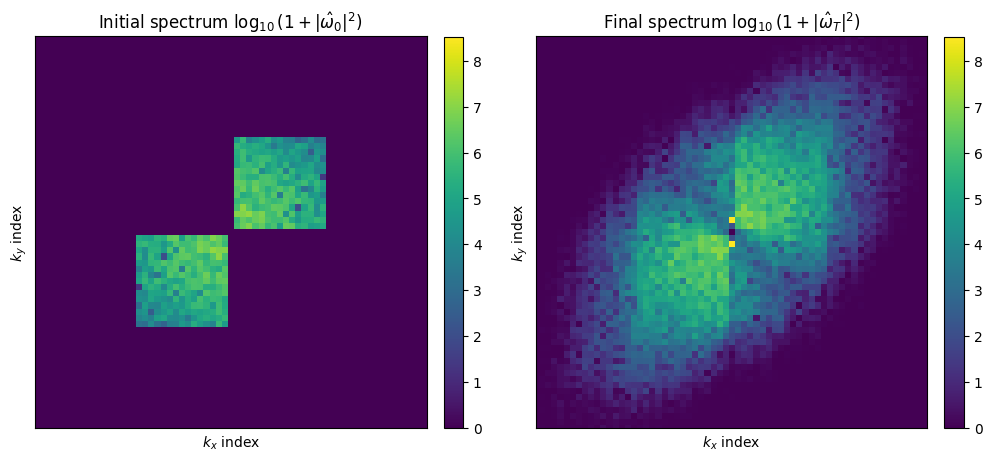

In [4]:
# ------------------------------------------------------
# Navier-Stokes dataset: 2D Fourier power spectrum
# ------------------------------------------------------
navier_fft_path = Path("/scratch/mnhagen/datasets/navier_stokes_multires/navier_stokes2D_S1000_N256_multi.h5")
sample_idx = 5
save_figure = False
save_path = Path("/home/mnhagen/thesis/figures/navier_fourier_power.png")

if not navier_fft_path.exists():
    raise FileNotFoundError(f"Could not find Navier-Stokes dataset at {navier_fft_path}")

with h5py.File(navier_fft_path, "r") as f:
    omega = np.array(f["omega"][sample_idx], dtype=np.float32)

omega_initial = omega[0]
omega_final = omega[-1]

def log10_power_spectrum(field: np.ndarray) -> np.ndarray:
    ft = np.fft.fftshift(np.fft.fft2(field))
    power = np.abs(ft) ** 2
    return np.log10(1.0 + power)

spec_initial = log10_power_spectrum(omega_initial)
spec_final = log10_power_spectrum(omega_final)
vmax = float(max(spec_initial.max(), spec_final.max()))

nky, nkx = spec_initial.shape
cx = nkx // 2
cy = nky // 2
half_window = nkx // 8
xlim = (cx - half_window, cx + half_window)
ylim = (cy - half_window, cy + half_window)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

im0 = axes[0].imshow(spec_initial, origin="lower", cmap="viridis", aspect="equal", vmin=0.0, vmax=vmax)
axes[0].set_title(r"Initial spectrum $\log_{10}(1 + |\hat{\omega}_0|^2)$")
axes[0].set_xlabel(r"$k_x$ index")
axes[0].set_ylabel(r"$k_y$ index")
axes[0].set_xlim(*xlim)
axes[0].set_ylim(*ylim)
axes[0].set_xticks([])
axes[0].set_yticks([])
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(spec_final, origin="lower", cmap="viridis", aspect="equal", vmin=0.0, vmax=vmax)
axes[1].set_title(r"Final spectrum $\log_{10}(1 + |\hat{\omega}_T|^2)$")
axes[1].set_xlabel(r"$k_x$ index")
axes[1].set_ylabel(r"$k_y$ index")
axes[1].set_xlim(*xlim)
axes[1].set_ylim(*ylim)
axes[1].set_xticks([])
axes[1].set_yticks([])
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

if save_figure:
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure to {save_path}")

plt.show()


Saved figure to /home/mnhagen/thesis/figures/cylinder_flow_input_output.png


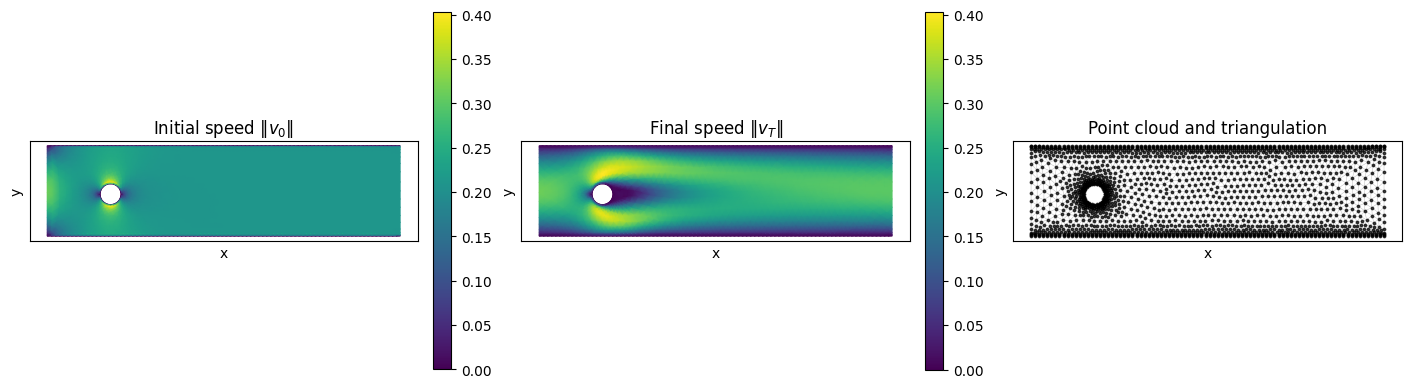

In [5]:
# ------------------------------------------------------
# Incompressible flow past a cylinder: initial/final/grid
# ------------------------------------------------------
import matplotlib.tri as mtri

cylinder_path = Path("/scratch/mnhagen/datasets/incompressible_euler/test.h5")
sample_key = "sample_000034"
t_initial = 0
t_final = -1
save_figure = True
save_path = Path("/home/mnhagen/thesis/figures/cylinder_flow_input_output.png")

if not cylinder_path.exists():
    raise FileNotFoundError(f"Could not find incompressible-flow dataset at {cylinder_path}")

with h5py.File(cylinder_path, "r") as f:
    sample = f[sample_key]
    pos = np.array(sample["pos"], dtype=np.float32)
    cells = np.array(sample["cells"], dtype=np.int32)
    vel = np.array(sample["vel"], dtype=np.float32)

speed_initial = np.linalg.norm(vel[t_initial], axis=-1)
speed_final = np.linalg.norm(vel[t_final], axis=-1)
vmax = float(max(speed_initial.max(), speed_final.max()))
triang = mtri.Triangulation(pos[:, 0], pos[:, 1], cells)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), constrained_layout=True)

im0 = axes[0].tripcolor(triang, speed_initial, shading="gouraud", cmap="viridis", vmin=0.0, vmax=vmax)
axes[0].set_title(r"Initial speed $\|v_0\|$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
axes[0].set_xticks([])
axes[0].set_yticks([])
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].tripcolor(triang, speed_final, shading="gouraud", cmap="viridis", vmin=0.0, vmax=vmax)
axes[1].set_title(r"Final speed $\|v_T\|$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")
axes[1].set_xticks([])
axes[1].set_yticks([])
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].triplot(triang, color="0.75", linewidth=0.35)
axes[2].scatter(pos[:, 0], pos[:, 1], s=3, c="black", alpha=0.7)
axes[2].set_title("Point cloud and triangulation")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_aspect("equal")
axes[2].set_xticks([])
axes[2].set_yticks([])

if save_figure:
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure to {save_path}")

plt.show()


Saved figure to /home/mnhagen/thesis/figures/nuclear_temperature_slice.png


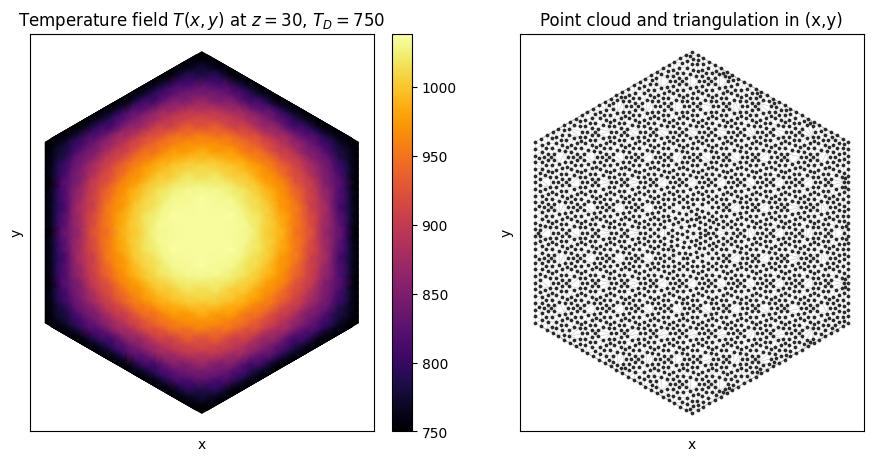

In [7]:
# ------------------------------------------------------
# Nuclear dataset: temperature slice and grid at chosen z
# ------------------------------------------------------
import matplotlib.tri as mtri

nuclear_path = Path("/scratch/ROM_datasets_nico/Data_Single_Stack/simulation_data_complete.h5")
temperature_value = 750
z_value = 30.0
z_tol = 1e-8
save_figure = True
save_path = Path("/home/mnhagen/thesis/figures/nuclear_temperature_slice.png")

if not nuclear_path.exists():
    raise FileNotFoundError(f"Could not find nuclear dataset at {nuclear_path}")

temperature_key = f"SS_{int(temperature_value)}"

with h5py.File(nuclear_path, "r") as f:
    coords = np.array(f["physical_field/coordinates"], dtype=np.float32)
    temp_group = f["physical_field/temperatures"]
    if temperature_key not in temp_group:
        available = sorted(int(k.split("_")[1]) for k in temp_group.keys())
        raise KeyError(
            f"Temperature {temperature_value} not available. Choose one of {available[:5]} ... {available[-5:]}"
        )
    temperature = np.array(temp_group[temperature_key], dtype=np.float32)

z_coords = coords[:, 2]
z_levels = np.unique(np.round(z_coords, 10))
z_actual = float(z_levels[np.argmin(np.abs(z_levels - z_value))])
mask = np.isclose(z_coords, z_actual, atol=z_tol)

if not np.any(mask):
    raise ValueError(f"No points found for z={z_value}")

xy = coords[mask, :2]
temperature_slice = temperature[mask]
triang = mtri.Triangulation(xy[:, 0], xy[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

im0 = axes[0].tripcolor(triang, temperature_slice, shading="gouraud", cmap="inferno")
axes[0].set_title(rf"Temperature field $T(x,y)$ at $z={z_actual:g}$, $T_D={temperature_value}$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
axes[0].set_xticks([])
axes[0].set_yticks([])
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].triplot(triang, color="0.75", linewidth=0.35)
axes[1].scatter(xy[:, 0], xy[:, 1], s=3, c="black", alpha=0.7)
axes[1].set_title(rf"Point cloud and triangulation in (x,y)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")
axes[1].set_xticks([])
axes[1].set_yticks([])

if save_figure:
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure to {save_path}")

plt.show()
